In [1]:
import torch
import time
import warnings
import os
import sys
from numba.core.errors import NumbaWarning

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from device import setup_device
from datasets.loading import get_data_loaders
from model.loading import load_model
from train.train_encoder import train_encoder
from analysis.visualization import visualize
from analysis.extraction import (
    extract_embeddings_from_model,
    extract_all_embeddings_from_model
)
from utils.checkpoint import save_checkpoint
from utils.config_io import save_configuration
from utils.cleanup import clear_gpu_cache, run_gc
from utils.printing import print_verbose
from utils.seed import set_seed
from setup.test_dir_setup import setup_testing_directory
from setup.training_setup import setup_training_environment, setup_train_config

In [2]:
warnings.filterwarnings("ignore", message=".*force_all_finite.*")
warnings.filterwarnings("ignore", category=NumbaWarning)
warnings.filterwarnings("ignore", message=".*verbose parameter is deprecated.*")
warnings.filterwarnings("ignore", message=".*epoch parameter in `scheduler.step.*")

In [3]:
clear_gpu_cache()
run_gc()
set_seed(0)

[02:01:13] [INFO] 🧹 Cleared GPU cache.
[02:01:13] [INFO] 🗑️  Garbage collector freed 10319 objects.
[02:01:13] [INFO] 🌱 Random seed set to 0.


In [4]:
config = {
    'verbose': True,
    'use_gpu_1_only': False,
    
    'backbone_model': 'resnet50',
    'pretrained': True,
    
    'base_dir': '../outputs/current',
    'test_name': '5_epoch_run',
    'initial_model_file_name': 'initial_model.pth',
    'best_model_file_name': 'best_model.pth',
    
    'data_folder': '../data/utkface/UTKFace',
    'augmentations': 'crop,flip,color,grayscale',
    
    'batch_size': 256,
    'train_size': 0.8,
    'num_epochs': 5,
    'learning_rate': 1e-3,
    'temperature': 0.5,
    
    'training_metrics': [
        "val_loss", "embedding_norm",
        "embedding_variance", "knn_accuracy",
        "knr_error", "spearman",
        "kendall", "grad_norm", "lr"
    ],
    'key_metric': 'train_loss',
    'mode': 'min',
    'use_early_stopping': False,
    'save_intermediate_models': True,
    'save_best_model': True,
    'write_to_tensorboard': True,
    'patience': 10,
    'delta': 1e-4,
    'nearest_neighbors': 5 # for knn or knr analysis
}

In [5]:
setup_testing_directory(config, create_unique_dir=True)
save_configuration(config)

[02:01:13] [INFO] ✅ Test directory created: ../outputs/current/5_epoch_run_20250528_0201
[02:01:13] [INFO] 📝 Configuration saved to ../outputs/current/5_epoch_run_20250528_0201/config.json


In [6]:
device, model, optimizer, scheduler, monitor = setup_training_environment(config)

train_loader, val_loader, train_loader_clean = get_data_loaders(
    config['data_folder'], config['augmentations'], 
    batch_size=config['batch_size'], train_size=config['train_size']
)

train_config = setup_train_config(
    device, model, optimizer, scheduler, monitor,
    train_loader, val_loader, train_loader_clean,
    config
)

[02:01:13] [INFO] ✅ CUDA is available: 2 GPU(s) visible
[02:01:13] [INFO] 🚀 Wrapping model in DataParallel over 2 GPUs
[02:01:13] [INFO] Enabled monitors: ['LoggingMonitor', 'OptimumMonitor', 'SaveModelMonitor', 'TensorboardMonitor']


In [7]:
# TRAINING CELL

# save initial model for comparison
save_checkpoint(model, config['initial_model_file'], epoch=0)

start_time = time.time()
train_encoder(train_config, verbose=config['verbose'])
end_time = time.time()

print_verbose(f"Training completed in: {end_time - start_time:.2f} seconds", config['verbose'])

[02:01:13] [INFO] Configuration check passed: 7 keys found.
[02:01:13] [INFO] Configuration check passed: 9 keys found.
[02:01:13] [INFO] Training on device: cuda


Training Epoch 1/5: 100%|█████████████████████████████████| 75/75 [ 1.57batch/s]


[02:02:01] [INFO] [Epoch 1] train_loss: 5.0857 (min)
[02:02:01] [INFO] ✅ New best train_loss: 5.0857 (min)


Training Epoch 2/5: 100%|█████████████████████████████████| 75/75 [ 1.59batch/s]


[02:02:48] [INFO] [Epoch 2] train_loss: 4.9876 (min)
[02:02:49] [INFO] ✅ New best train_loss: 4.9876 (min)


...

[02:03:36] [INFO] [Epoch 3] train_loss: 4.9423 (min)
[02:03:36] [INFO] ✅ New best train_loss: 4.9423 (min)


Training Epoch 4/5: 100%|█████████████████████████████████| 75/75 [ 1.58batch/s]


[02:04:24] [INFO] [Epoch 4] train_loss: 4.9173 (min)
[02:04:24] [INFO] ✅ New best train_loss: 4.9173 (min)


Training Epoch 5/5: 100%|█████████████████████████████████| 75/75 [ 1.57batch/s]


[02:05:12] [INFO] [Epoch 5] train_loss: 4.8921 (min)
[02:05:12] [INFO] ✅ New best train_loss: 4.8921 (min)
[02:05:12] [INFO] Training complete!
[02:05:12] [INFO] Training completed in: 238.86 seconds


In [8]:
# ANALYSIS CELL

# Embedding extraction for visualization
initial_model_embeddings, initial_model_labels = extract_embeddings_from_model(
    model, config['initial_model_file'], config['data_folder'], device, config['verbose']
)
best_model_embeddings, best_model_labels = extract_embeddings_from_model(
    model, config['best_model_file'], config['data_folder'], device, config['verbose']
)
embeddings_list, labels_list = extract_all_embeddings_from_model(
    model, config['analysis_dir'], config['data_folder'],
    device, verbose=config['verbose']
)

# Parameters for visualization
vis_args = {
    'umap_data': [
        {'embeddings': initial_model_embeddings, 'labels': initial_model_labels, 
         'title': 'Initial Model UMAP Projection', 'figsize': (5, 5)},
        {'embeddings': best_model_embeddings, 'labels': best_model_labels, 
         'title': 'Best Model UMAP Projection', 'figsize': (5, 5)}
    ],
    'similarity_matrix_data': [
        {'embeddings': initial_model_embeddings, 'labels': initial_model_labels, 
         'title': 'Initial Model Feature Similarity Matrix', 'figsize': (5, 5)},
        {'embeddings': best_model_embeddings, 'labels': best_model_labels, 
         'title': 'Best Model Feature Similarity Matrix', 'figsize': (5, 5)}
    ],
    'umap_all_data': {
        'embeddings_list': embeddings_list,
        'labels_list': labels_list,
        'figsize': (3, 3),
        'max_cols': 5,
        'num_neighbors': 15
    }
}

# Visualizations to run
selected = ['umap', 'similarity_matrix', 'umap_all']

[02:05:12] [INFO] Loaded model from ../outputs/current/5_epoch_run_20250528_0201/initial_model.pth


Extracting Embeddings: 100%|████████████████████████████| 371/371 [19.05batch/s]


[02:05:32] [INFO] Shape of embeddings: (23708, 128)
[02:05:32] [INFO] Memory usage of embeddings: 11.58 MB
[02:05:32] [INFO] Loaded model from ../outputs/current/5_epoch_run_20250528_0201/best_model.pth


Extracting Embeddings: 100%|████████████████████████████| 371/371 [19.48batch/s]


[02:05:51] [INFO] Shape of embeddings: (23708, 128)
[02:05:51] [INFO] Memory usage of embeddings: 11.58 MB
[02:05:51] [INFO] Loaded model from ../outputs/current/5_epoch_run_20250528_0201/analysis/model_epoch_001.pth


...

Extracting Embeddings: 100%|████████████████████████████| 371/371 [19.73batch/s]


[02:06:48] [INFO] Loaded model from ../outputs/current/5_epoch_run_20250528_0201/analysis/model_epoch_004.pth


Extracting Embeddings: 100%|████████████████████████████| 371/371 [19.70batch/s]


[02:07:07] [INFO] Loaded model from ../outputs/current/5_epoch_run_20250528_0201/analysis/model_epoch_005.pth


Extracting Embeddings: 100%|████████████████████████████| 371/371 [19.33batch/s]


[02:07:26] [INFO] [visualize] Running: umap
[02:07:48] [INFO] [plot_umap] embeddings: (23708, 128), labels: (23708,)


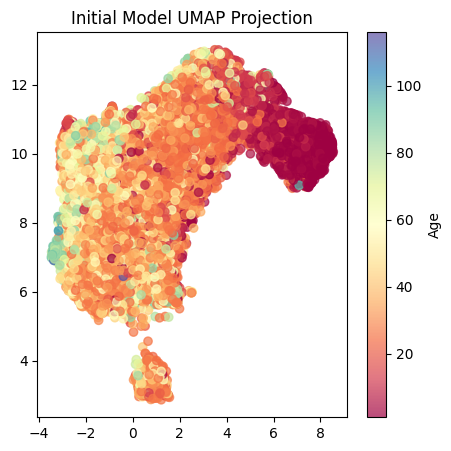

[02:07:57] [INFO] [plot_umap] embeddings: (23708, 128), labels: (23708,)


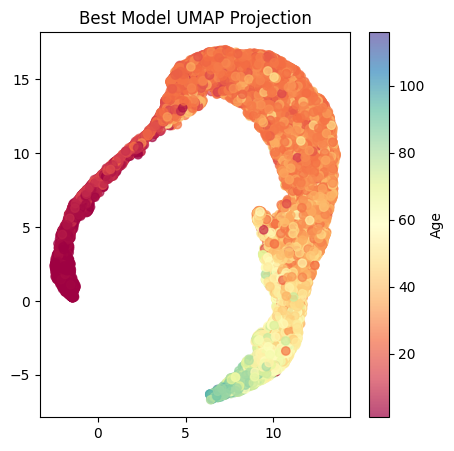

[02:07:57] [INFO] [visualize] Running: similarity_matrix
[02:07:58] [INFO] [plot_similarity_matrix] embeddings: torch.Size([2000, 128]), labels: torch.Size([2000])


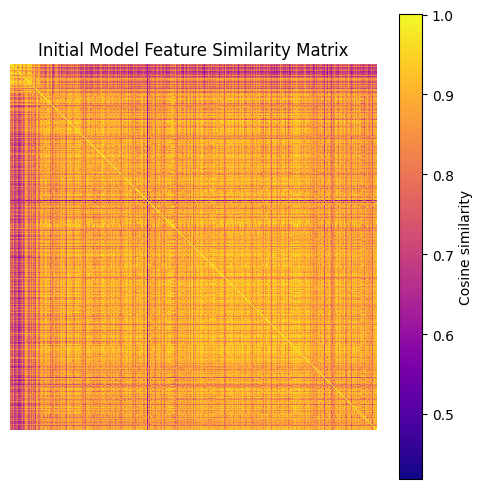

[02:07:59] [INFO] [plot_similarity_matrix] embeddings: torch.Size([2000, 128]), labels: torch.Size([2000])


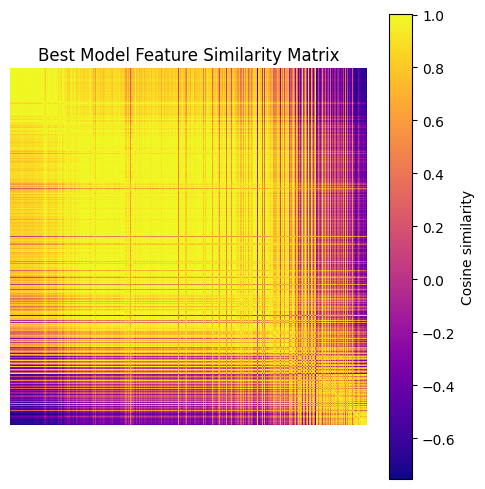

[02:07:59] [INFO] [visualize] Running: umap_all
[02:08:07] [INFO] [plot_umap_all_epochs_grid] Epoch 0: (23708, 128), (23708,)
[02:08:15] [INFO] [plot_umap_all_epochs_grid] Epoch 1: (23708, 128), (23708,)
[02:08:23] [INFO] [plot_umap_all_epochs_grid] Epoch 2: (23708, 128), (23708,)
[02:08:31] [INFO] [plot_umap_all_epochs_grid] Epoch 3: (23708, 128), (23708,)
[02:08:38] [INFO] [plot_umap_all_epochs_grid] Epoch 4: (23708, 128), (23708,)


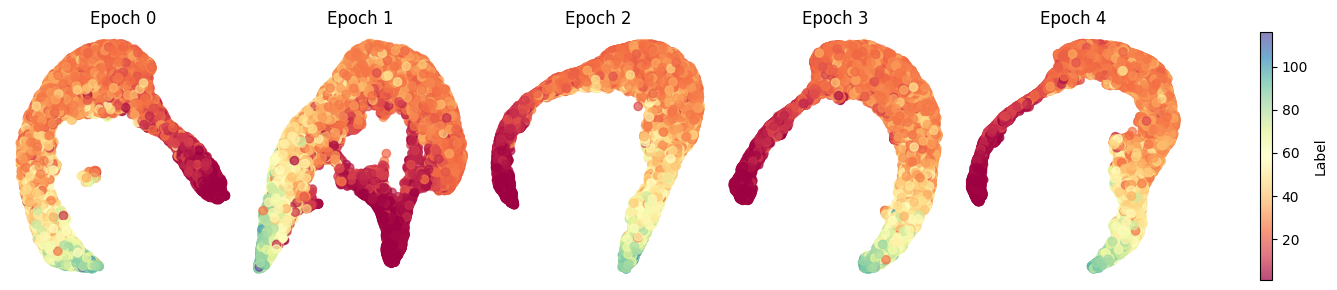

[02:08:40] [INFO] Visualization computed in: 73.25 seconds


In [9]:
# VISUALIZATION CELL

start_time = time.time()
visualize(selected, vis_args, verbose=config['verbose'])
end_time = time.time()

print_verbose(f"Visualization computed in: {end_time - start_time:.2f} seconds", config['verbose'])